## How are in-demand skills trending for Data Analysts?

In [61]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns

ds = load_dataset("lukebarousse/data_jobs")                                 #loading the dataset
df = ds['train'].to_pandas()                                                #converting to dataframe type
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])               # job_posted_date cleanup

def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
    
df['job_skills'] = df['job_skills'].apply(clean_list)                       # job_skill cleanup

In [62]:
df_DA_ind = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()
df_DA_ind['job_posted_month'] = df_DA_ind['job_posted_date'].dt.month

df_DA_ind = df_DA_ind.explode('job_skills')

df_DA_pivot = df_DA_ind.pivot_table(index = 'job_posted_month', columns= 'job_skills', aggfunc= 'size', fill_value= 0)
df_DA_pivot

job_skills,airflow,alteryx,angular,ansible,arch,asana,asp.net,assembly,atlassian,aurora,...,vue.js,watson,webex,windows,wire,word,workfront,wrike,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,3,21,1,0,0,0,1,0,0,0,...,0,0,1,4,1,37,0,0,0,3
2,7,17,1,0,2,0,0,1,0,1,...,0,1,1,5,0,24,0,0,0,0
3,6,16,2,1,0,0,0,1,1,0,...,0,0,0,5,0,27,0,0,0,2
4,8,8,1,0,4,0,1,2,0,0,...,0,0,1,4,0,27,0,0,0,1
5,5,13,0,0,1,0,0,0,0,0,...,0,0,0,5,0,13,0,0,0,0
6,5,22,1,0,0,0,1,0,0,1,...,0,0,0,1,0,12,1,0,0,1
7,10,13,2,0,1,0,0,0,0,1,...,0,4,0,4,0,22,0,0,0,2
8,19,25,2,0,0,0,0,0,2,0,...,0,1,0,4,0,31,0,0,1,1
9,4,14,0,0,0,2,0,0,1,5,...,0,0,0,2,0,28,0,0,1,2


In [63]:
df_DA_pivot.loc['total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('total')

df_DA_pivot

job_skills,sql,python,excel,tableau,power bi,r,sas,azure,aws,powerpoint,...,hugging face,fastapi,kotlin,powerbi,mariadb,sqlite,clickup,suse,twilio,centos
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,305,216,218,159,98,89,128,46,32,43,...,0,1,0,0,0,0,0,0,1,0
2,209,148,156,116,75,67,82,26,33,25,...,0,0,0,0,0,0,0,0,0,0
3,229,151,138,125,76,58,62,45,38,29,...,0,0,0,1,0,0,0,1,0,0
4,204,143,138,98,83,56,52,40,31,28,...,0,0,0,0,0,0,0,0,0,0
5,155,101,106,71,61,42,30,33,22,19,...,0,0,0,0,0,0,0,0,0,1
6,193,150,115,114,77,76,74,37,32,24,...,0,0,0,0,0,0,0,0,0,0
7,245,161,174,124,93,67,78,39,31,31,...,1,0,1,0,0,0,0,0,0,0
8,317,216,192,152,127,112,98,52,63,40,...,0,0,0,0,0,0,0,0,0,0
9,341,229,228,195,168,100,92,35,41,29,...,0,0,0,0,0,0,0,0,0,0


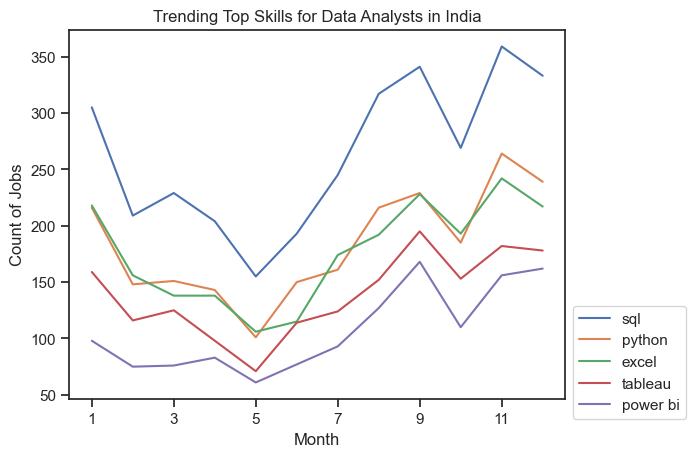

In [64]:
df_plot = df_DA_pivot.iloc[:,:5].plot(kind='line')
plt.title('Trending Top Skills for Data Analysts in India')
plt.xlabel('Month')
plt.ylabel('Count of Jobs')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.1))
plt.show()

##### Converting the totals to percentages for better understanding


In [65]:
df_total = df_DA_ind.groupby('job_posted_month').size()

df_DA_percent = df_DA_pivot.div(df_total/100, axis = 0)

df_plot = df_DA_percent.iloc[:,:5]

df_DA_percent = df_DA_percent.reset_index()
df_DA_percent['job_posted_month_name'] = df_DA_percent['job_posted_month'].apply(lambda x : pd.to_datetime(x, format = '%m').strftime('%b'))
df_DA_percent = df_DA_percent.set_index('job_posted_month_name')
df_DA_percent = df_DA_percent.drop(columns='job_posted_month')

df_plot = df_DA_percent.iloc[:, :5]






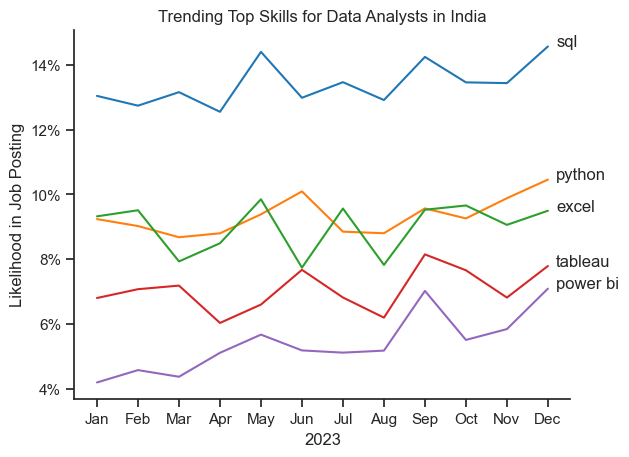

In [66]:
sns.lineplot(data= df_plot, dashes= False, palette= 'tab10')
sns.set_theme(style='ticks')

plt.title('Trending Top Skills for Data Analysts in India')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
sns.despine()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals= 0))
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1,i], df_plot.columns[i])
    